# Voxel Encoding

In [5]:
%%capture
! pip install himalaya

In [6]:
!pip install --upgrade scipy

You should consider upgrading via the '/gpfs/home1/scur0410/NeuroNLP/NeuroNLP/neuroai/bin/python -m pip install --upgrade pip' command.


In [7]:
import os
import numpy as np
from scipy.io import loadmat
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
from himalaya.kernel_ridge import KernelRidgeCV
from himalaya.scoring import correlation_score 

In [24]:
# For the .mat files (Experiment 2 and Experiment 3)
mat_exp2 = "/home/scur0410/NeuroNLP/NeuroNLP/data/M02/data_243sentences.mat"
mat_exp3 = "/home/scur0410/NeuroNLP/NeuroNLP/data/M02/data_384sentences.mat"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen Embedder
embed_dir_exp2 = "/home/scur0410/NeuroNLP/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment2_243"
embed_dir_exp3 = "/home/scur0410/NeuroNLP/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment3_384"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen
llm_dir_exp2 = "/home/scur0410/NeuroNLP/NeuroNLP/results/embeddings/Qwen/Experiment2_243"
llm_dir_exp3 = "/home/scur0410/NeuroNLP/NeuroNLP/results/embeddings/Qwen/Experiment3_384"
num_layers = 37

In [25]:
def get_language_responses(mat_path):
    data = loadmat(mat_path, simplify_cells=True)
    target_index = np.where(data['meta']['atlases'] == 'languageLH')[0].item()
    column_indexes = np.concatenate([arr - 1 for arr in data['meta']['roiColumns'][target_index]], axis=0)
    # brain_responses = data['examples_passages'][:, column_indexes]
    brain_responses = data['examples_passagesentences'][:, column_indexes]
    print(f"Dimensionality of brain responses: {brain_responses.shape}")
    return brain_responses

In [26]:
y_exp2 = get_language_responses(mat_exp2)
y_exp3 = get_language_responses(mat_exp3)


/home/scur0410/NeuroNLP/NeuroNLP/neuroai/lib64/python3.9/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Dimensionality of brain responses: (243, 4930)
Dimensionality of brain responses: (384, 4930)


In [27]:
Y = np.concatenate([y_exp2, y_exp3], axis=0)
n_splits = 5
kf = KFold(n_splits=n_splits)
alphas = np.logspace(1, 20, 20)
_, n_voxels = Y.shape

layer_performances = {}

In [29]:
# Initialize dictionaries to store performance for both models
layer_performances = {}  # For Qwen model
layer_performances_embedding = {}  # For Qwen Embedding model


for layer_idx in range(num_layers):
    # Load the embeddings for the Qwen model (exp2 and exp3)
    x_exp2 = np.load(os.path.join(llm_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_exp3 = np.load(os.path.join(llm_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    X = np.concatenate([x_exp2, x_exp3], axis=0)

    accs_train = np.empty((n_splits, n_voxels))
    accs_test = np.empty((n_splits, n_voxels))

    # Perform cross-validation for Qwen model
    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X[train_index, :], X[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test[i] = correlation_score(Y_test, preds_test)

    # Compute mean test and train accuracies for Qwen model
    mean_test_acc = accs_test.mean(axis=0).mean()
    mean_train_acc = accs_train.mean(axis=0).mean()
    layer_performances[layer_idx] = mean_test_acc
    
    print(f"Qwen Model - Layer {layer_idx} Test Accuracy: {mean_test_acc:.4f}")
    print(f"Qwen Model - Layer {layer_idx} Train Accuracy: {mean_train_acc:.4f}")

    # Now for Qwen Embedding Model - repeat the process with its respective embeddings
    # Load the embeddings for Qwen Embedding model (exp2 and exp3)
    x_exp2_embedding = np.load(os.path.join(embed_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_exp3_embedding = np.load(os.path.join(embed_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    X_embedding = np.concatenate([x_exp2_embedding, x_exp3_embedding], axis=0)

    accs_train_embedding = np.empty((n_splits, n_voxels))
    accs_test_embedding = np.empty((n_splits, n_voxels))

    # Perform cross-validation for Qwen Embedding model
    for i, (train_index, test_index) in enumerate(kf.split(X_embedding)):
        X_train, X_test = X_embedding[train_index, :], X_embedding[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train_embedding[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test_embedding[i] = correlation_score(Y_test, preds_test)

    # Compute mean test and train accuracies for Qwen Embedding model
    mean_test_acc_embedding = accs_test_embedding.mean(axis=0).mean()
    mean_train_acc_embedding = accs_train_embedding.mean(axis=0).mean()
    layer_performances_embedding[layer_idx] = mean_test_acc_embedding
    
    print(f"Qwen Embedding Model - Layer {layer_idx} Test Accuracy: {mean_test_acc_embedding:.4f}")
    print(f"Qwen Embedding Model - Layer {layer_idx} Train Accuracy: {mean_train_acc_embedding:.4f}")

Qwen Model - Layer 0 Test Accuracy: 0.0054
Qwen Model - Layer 0 Train Accuracy: 0.0390
Qwen Embedding Model - Layer 0 Test Accuracy: 0.0000
Qwen Embedding Model - Layer 0 Train Accuracy: 0.0000
Qwen Model - Layer 1 Test Accuracy: 0.1495
Qwen Model - Layer 1 Train Accuracy: 0.3443
Qwen Embedding Model - Layer 1 Test Accuracy: 0.1714
Qwen Embedding Model - Layer 1 Train Accuracy: 0.3673
Qwen Model - Layer 2 Test Accuracy: 0.1322
Qwen Model - Layer 2 Train Accuracy: 0.3251
Qwen Embedding Model - Layer 2 Test Accuracy: 0.1862
Qwen Embedding Model - Layer 2 Train Accuracy: 0.4068
Qwen Model - Layer 3 Test Accuracy: 0.1178
Qwen Model - Layer 3 Train Accuracy: 0.2971
Qwen Embedding Model - Layer 3 Test Accuracy: 0.2002
Qwen Embedding Model - Layer 3 Train Accuracy: 0.4309
Qwen Model - Layer 4 Test Accuracy: 0.1665
Qwen Model - Layer 4 Train Accuracy: 0.3740
Qwen Embedding Model - Layer 4 Test Accuracy: 0.2223
Qwen Embedding Model - Layer 4 Train Accuracy: 0.4569
Qwen Model - Layer 5 Test Accu

In [31]:
output_dir = "/home/scur0410/NeuroNLP/NeuroNLP/results"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "qwen_layer_performances.npy")
np.save(output_file, layer_performances)

output_file_embedding = os.path.join(output_dir, "qwen_embedding_layer_performances.npy")
np.save(output_file_embedding, layer_performances_embedding)

In [ ]:
output_dir = "/home/scur0412/NeuroNLP/results"
output_file = os.path.join(output_dir, "qwen_layer_performances.npy")

qwen_embedding_output_file = os.path.join(output_dir, "qwen_embedding_layer_performances.npy")

In [41]:
%pip install matplotlib

  Using cached matplotlib-3.9.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
     |████████████████████████████████| 122 kB 24.4 MB/s            
  Using cached fonttools-4.60.2-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.8 MB)
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (321 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
You should consider upgrading via the '/home/scur0410/NeuroNLP/NeuroNLP/neuroai/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


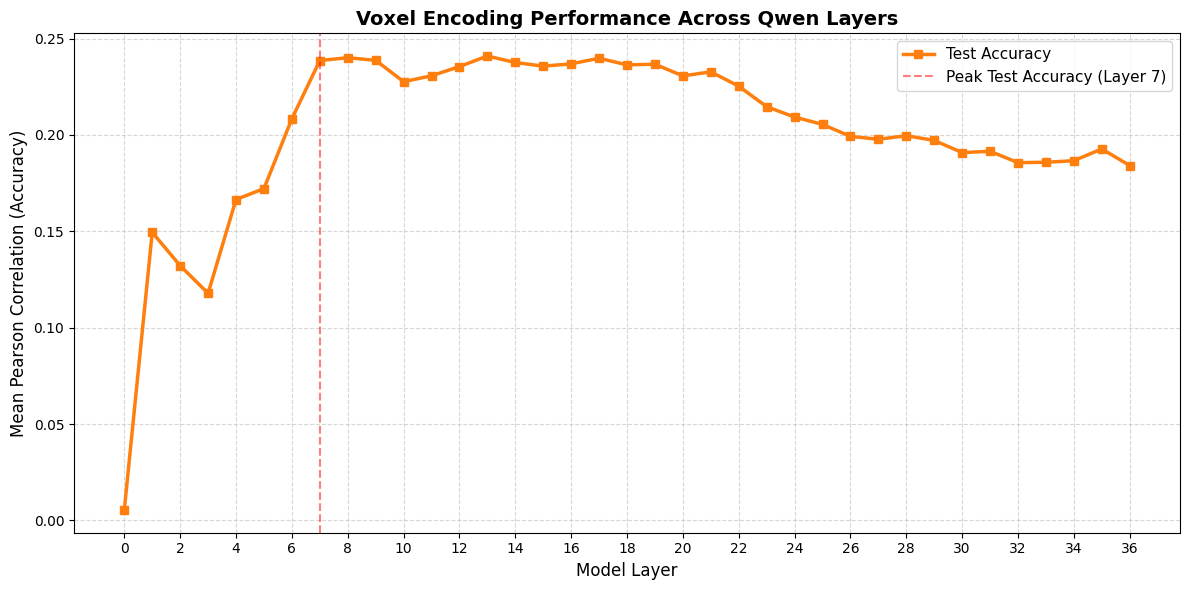

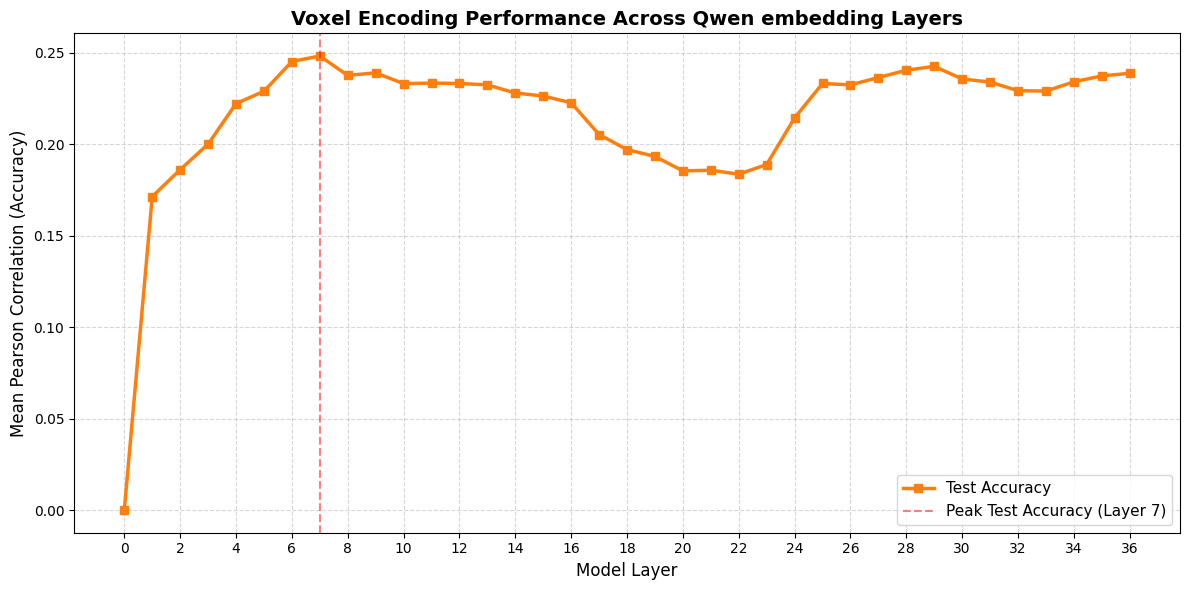

In [44]:
layer_performances = np.load(output_file, allow_pickle=True).item()

layers = sorted(layer_performances.keys())
test_acc = [layer_performances[layer] for layer in layers]

plt.figure(figsize=(12, 6))

plt.plot(layers, test_acc, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2.5, linestyle='-')

plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='Peak Test Accuracy (Layer 7)')

plt.title("Voxel Encoding Performance Across Qwen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Model Layer", fontsize=12)
plt.ylabel("Mean Pearson Correlation (Accuracy)", fontsize=12)
plt.xticks(np.arange(0, len(layers), 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

layer_performances = np.load(
output_file_embedding, allow_pickle=True).item()

layers = sorted(layer_performances.keys())
test_acc = [layer_performances[layer] for layer in layers]

plt.figure(figsize=(12, 6))

plt.plot(layers, test_acc, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2.5, linestyle='-')

plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='Peak Test Accuracy (Layer 7)')

plt.title("Voxel Encoding Performance Across Qwen embedding Layers", fontsize=14, fontweight='bold')
plt.xlabel("Model Layer", fontsize=12)
plt.ylabel("Mean Pearson Correlation (Accuracy)", fontsize=12)
plt.xticks(np.arange(0, len(layers), 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()